In [8]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../Mamoth Modules")
sys.path.insert(0, "../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [9]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [10]:
shape_file = pd.read_csv(f'data/{NUTS0}_{NUTS2}_Timeline_Biweekly_2010-2021_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'data/{NUTS0}_{NUTS2}_WNV_Timeline_2010-2021.csv', encoding=enc)

In [11]:
shape_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-01,2010,1,2009-12-07,40.659996,22.397246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.659996,22.397246,14192.0,14017.0,40.659996,22.397246,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,2010-01-01,40.650186,22.350102,0.019869,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.019869,0.019869
1,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-16,2010,1,2009-12-07,40.659996,22.397246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,40.659996,22.397246,14129.0,13839.0,40.659996,22.397246,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,2010-01-16,40.650186,22.350102,21.994516,2010-01-09,2010-01-02,2010-01-09,2010-01-02,1.172702,21.024027
2,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-01,2010,1,2009-12-07,40.677962,22.464619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.677962,22.464619,14251.0,13995.0,40.677962,22.464619,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,2010-01-01,40.650186,22.450103,0.021185,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.021185,0.021185
3,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-16,2010,1,2009-12-07,40.677962,22.464619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,40.677962,22.464619,14188.0,13820.0,40.677962,22.464619,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,2010-01-16,40.650186,22.450103,19.148625,2010-01-09,2010-01-02,2010-01-09,2010-01-02,1.418397,18.804765
4,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2010-01-01,2010,1,2009-12-07,40.624063,22.491569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.624063,22.491569,14239.0,14024.0,40.624063,22.491569,14020.000000,13876.500000,14157.333333,13762.727273,14546.416667,13868.470588,15075.142857,14133.833333,2010-01-01,40.650186,22.450103,0.021185,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.021185,0.021185


In [12]:
wnv_file.head()

,lau1,nuts2,dt_placement,case
0,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-01,0
1,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-16,0
2,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-01,0
3,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-16,2
4,αλεξανδρειας,κεντρικης μακεδονιας,2010-08-01,11


In [13]:
shape_file.rename(columns={"region": "nuts2"}, inplace=True)

In [14]:
process_greek(shape_file, 'lau1')
process_greek(shape_file, 'nuts2')

In [15]:
shape_file = shape_file.rename(columns=lambda x: re.sub('_new', '', x))

In [16]:
shape_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [17]:
shape_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14192.0,14017.0,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,0.019869,0.019869,0.019869
1,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14129.0,13839.0,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,21.994516,1.172702,21.024027
2,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14251.0,13995.0,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,0.021185,0.021185,0.021185
3,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14188.0,13820.0,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,19.148625,1.418397,18.804765
4,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14239.0,14024.0,14020.000000,13876.500000,14157.333333,13762.727273,14546.416667,13868.470588,15075.142857,14133.833333,0.021185,0.021185,0.021185


In [18]:
wnv_file.head(5)

,lau1,nuts2,dt_placement,case
0,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-01,0
1,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-16,0
2,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-01,0
3,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-16,2
4,αλεξανδρειας,κεντρικης μακεδονιας,2010-08-01,11


In [19]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_shapefile = shape_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_shapefile:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")


['ηρωικης πολης ναουσας']

Length: 1


In [20]:
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολης ναουσας','ναουσας'))

In [21]:
## Check again

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_shapefile = shape_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_shapefile:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [22]:
merged = shape_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )

In [23]:
merged

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14192.0,14017.0,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,0.019869,0.019869,0.019869,NaN
1,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14129.0,13839.0,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,21.994516,1.172702,21.024027,NaN
2,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14251.0,13995.0,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,0.021185,0.021185,0.021185,NaN
3,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14188.0,13820.0,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,19.148625,1.418397,18.804765,NaN
4,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14239.0,14024.0,14020.000000,13876.500000,14157.333333,13762.727273,14546.416667,13868.470588,15075.142857,14133.833333,0.021185,0.021185,0.021185,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51835,χαλκηδονος,κεντρικης μακεδονιας,22.73880,40.73560,2021-12-16,2021,12,0.251805,-0.073830,-0.213668,0.073830,0.285509,-0.033475,-0.240839,0.033475,0.049812,0.042605,0.035642,0.042605,NaN,NaN,14123.750000,13539.555556,14496.076923,13847.111111,14702.923077,13852.117647,14842.076923,14030.071429,1117.097203,59.682183,90.624163,NaN
51836,ωραιοκαστρου,κεντρικης μακεδονιας,22.94073,40.74476,2021-12-01,2021,12,0.586417,0.234927,-0.449285,-0.234927,0.449600,0.105007,-0.355143,-0.105007,0.078153,0.070156,0.061729,0.070156,NaN,NaN,14048.333333,13653.142857,14364.266667,13877.850000,14443.200000,13843.214286,14749.466667,13954.000000,1161.068238,11.701603,42.697279,NaN
51837,ωραιοκαστρου,κεντρικης μακεδονιας,22.94073,40.74476,2021-12-16,2021,12,0.586417,0.234927,-0.449285,-0.234927,0.449600,0.105007,-0.355143,-0.105007,0.078153,0.070156,0.061729,0.070156,NaN,NaN,14048.333333,13653.142857,14364.266667,13877.850000,14443.200000,13843.214286,14749.466667,13954.000000,1283.646776,62.627688,122.578538,NaN
51838,ωραιοκαστρου,κεντρικης μακεδονιας,22.94073,40.79866,2021-12-01,2021,12,0.391987,0.052467,-0.309246,-0.052467,0.333284,-0.004223,-0.285973,0.004223,0.100953,0.054073,0.055935,0.054073,NaN,NaN,13945.909091,13627.000000,14269.133333,13878.111111,14559.923077,13795.000000,14824.533333,13996.923077,1161.068238,11.701603,42.697279,NaN


In [24]:
merged = fillna(merged,{'case': 0})

In [25]:
merged['case'].value_counts()

0.0     50324
1.0       901
2.0       306
3.0       118
4.0        82
        ...  
8.0        10
18.0        5
12.0        5
9.0         5
11.0        4
Name: case, Length: 13, dtype: int64

In [26]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [27]:
dataset = grouped.mean()

In [28]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.483978,40.644680,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14254.250000,13999.75,14038.416667,13841.023810,14155.566667,13756.638258,14594.434470,13873.434314,15130.728022,14121.996545,0.015560,0.015560,0.015560,0.0
1,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,21.940791,40.977027,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14223.727273,13957.00,13869.513312,13744.208815,13867.496753,13711.131484,14224.720029,13763.856185,14598.699282,13988.568853,0.248551,0.248551,0.248551,0.0
2,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.891980,40.656030,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.00,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,0.000000,0.000000,0.000000,0.0
3,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.982527,40.915102,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14313.500000,14075.75,14060.466667,13849.123810,14119.082323,13755.281926,14385.038636,13831.014839,14687.678342,14072.125000,0.055994,0.055994,0.055994,0.0
4,2010-01-01,αριστοτελη,κεντρικης μακεδονιας,23.691080,40.495934,2010.0,1.0,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.000000,0.000000,0.000000,0.000000,14419.500000,14040.25,14128.136995,13903.784226,14068.485978,13793.050847,14424.248689,13827.634516,14601.602841,14032.383996,1.750566,1.750566,1.750566,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10939,2021-12-16,σιθωνιας,κεντρικης μακεδονιας,23.828106,40.110264,2021.0,12.0,0.533019,0.216610,-0.406977,-0.216610,0.525750,0.209897,-0.401147,-0.209897,0.039324,0.061157,0.034067,0.061157,NaN,NaN,14131.712105,13798.223434,14309.703516,13947.082353,14391.596265,13919.650000,14628.870760,14012.311944,2180.544076,75.411011,161.899452,0.0
10940,2021-12-16,σιντικης,κεντρικης μακεδονιας,23.388058,41.313484,2021.0,12.0,0.126568,-0.005089,-0.091934,0.005089,0.122184,0.074416,-0.090676,-0.074416,0.027041,0.050254,0.035247,0.050254,NaN,NaN,13895.539899,13525.684019,14245.385339,13792.929034,14454.229025,13724.788455,14684.146065,13885.721902,1562.784564,141.524710,215.682589,0.0
10941,2021-12-16,σκυδρας,κεντρικης μακεδονιας,22.146700,40.822940,2021.0,12.0,0.424823,0.260152,-0.272072,-0.260152,0.423505,0.247285,-0.273696,-0.247285,0.023733,0.043566,0.046055,0.043566,NaN,NaN,14058.867424,13572.800000,14466.912879,13843.509211,14590.182353,13825.676471,14830.247917,13975.117647,997.526490,56.599638,67.029917,0.0
10942,2021-12-16,χαλκηδονος,κεντρικης μακεδονιας,22.723020,40.753567,2021.0,12.0,0.255928,-0.052975,-0.231818,0.052975,0.276006,-0.030417,-0.240922,0.030417,0.059156,0.056067,0.041252,0.056067,NaN,NaN,14117.840476,13553.251852,14456.092308,13851.944444,14692.609280,13852.974401,14831.047863,14012.847619,1117.097203,59.682183,90.624163,0.0


In [29]:
dataset = dataset.astype({'case': 'int'})

In [30]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [31]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [32]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [33]:
with open(f'data/{NUTS0}_WNV_{NUTS2}_LAU1_mapping.json', 'w', encoding=enc) as file:
     json.dump(lau1_map,file,sort_keys=True, indent=4, ensure_ascii=False)

In [34]:
dataset["lau1_id"] = dataset["lau1"].map(lau1_map)

dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [35]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14254.250000,13999.75,14038.416667,13841.023810,14155.566667,13756.638258,14594.434470,13873.434314,15130.728022,14121.996545,0.015560,0.015560,0.015560,0,1,53,46.44911,8,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
1,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14223.727273,13957.00,13869.513312,13744.208815,13867.496753,13711.131484,14224.720029,13763.856185,14598.699282,13988.568853,0.248551,0.248551,0.248551,0,1,53,46.48134,9,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
2,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.00,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,0.000000,0.000000,0.000000,0,1,53,46.65786,17,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
3,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14313.500000,14075.75,14060.466667,13849.123810,14119.082323,13755.281926,14385.038636,13831.014839,14687.678342,14072.125000,0.055994,0.055994,0.055994,0,1,53,47.42581,33,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
4,2010-01-01,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2010,1,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.000000,0.000000,0.000000,0.000000,14419.500000,14040.25,14128.136995,13903.784226,14068.485978,13793.050847,14424.248689,13827.634516,14601.602841,14032.383996,1.750566,1.750566,1.750566,0,1,53,46.91682,27,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10939,2021-12-16,σιθωνιας,κεντρικης μακεδονιας,23.82811,40.11026,2021,12,0.533019,0.216610,-0.406977,-0.216610,0.525750,0.209897,-0.401147,-0.209897,0.039324,0.061157,0.034067,0.061157,NaN,NaN,14131.712105,13798.223434,14309.703516,13947.082353,14391.596265,13919.650000,14628.870760,14012.311944,2180.544076,75.411011,161.899452,0,16,50,46.65417,16,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
10940,2021-12-16,σιντικης,κεντρικης μακεδονιας,23.38806,41.31348,2021,12,0.126568,-0.005089,-0.091934,0.005089,0.122184,0.074416,-0.090676,-0.074416,0.027041,0.050254,0.035247,0.050254,NaN,NaN,13895.539899,13525.684019,14245.385339,13792.929034,14454.229025,13724.788455,14684.146065,13885.721902,1562.784564,141.524710,215.682589,0,16,50,47.47426,35,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
10941,2021-12-16,σκυδρας,κεντρικης μακεδονιας,22.14670,40.82294,2021,12,0.424823,0.260152,-0.272072,-0.260152,0.423505,0.247285,-0.273696,-0.247285,0.023733,0.043566,0.046055,0.043566,NaN,NaN,14058.867424,13572.800000,14466.912879,13843.509211,14590.182353,13825.676471,14830.247917,13975.117647,997.526490,56.599638,67.029917,0,16,50,46.44339,7,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
10942,2021-12-16,χαλκηδονος,κεντρικης μακεδονιας,22.72302,40.75357,2021,12,0.255928,-0.052975,-0.231818,0.052975,0.276006,-0.030417,-0.240922,0.030417,0.059156,0.056067,0.041252,0.056067,NaN,NaN,14117.840476,13553.251852,14456.092308,13851.944444,14692.609280,13852.974401,14831.047863,14012.847619,1117.097203,

<AxesSubplot:>

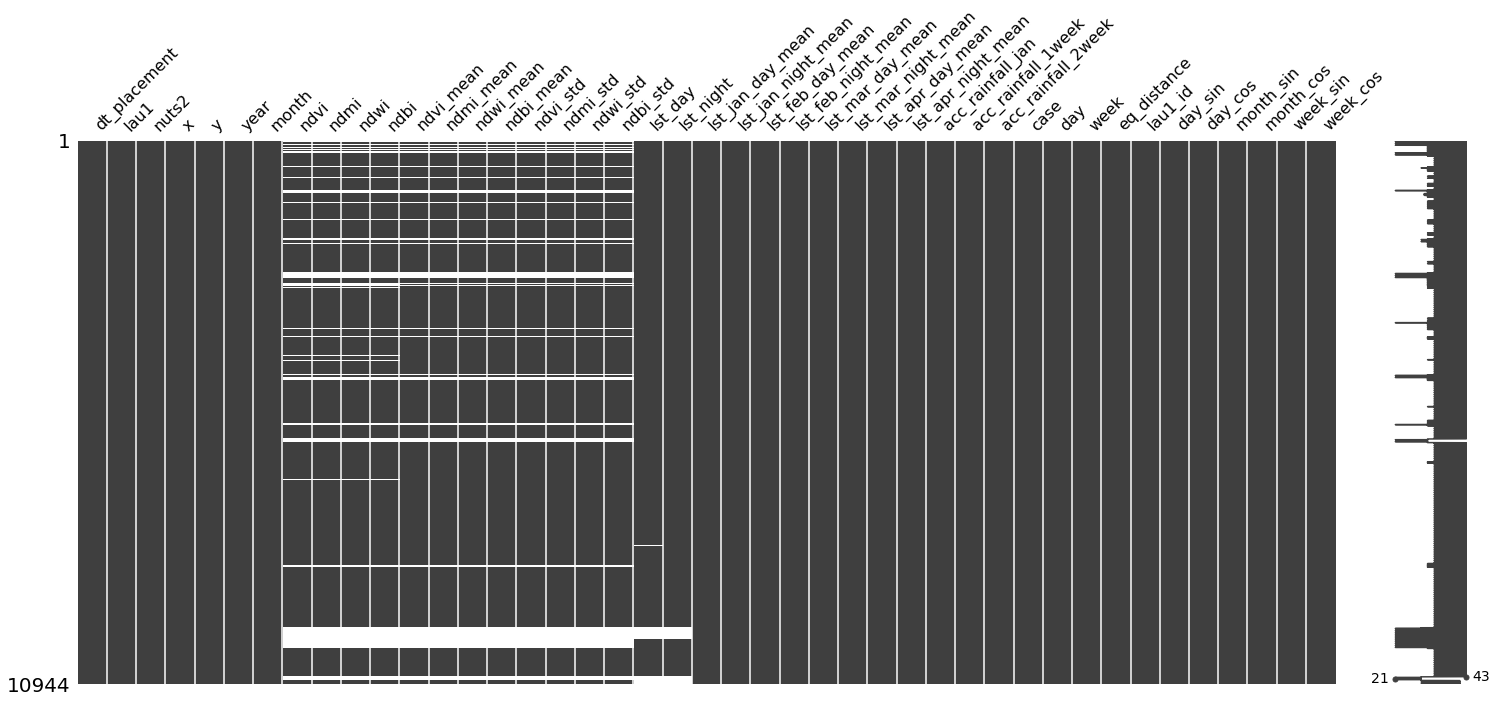

In [36]:
missingno.matrix(dataset)

In [37]:
df_demographics = pd.read_csv(f'data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [38]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [39]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [40]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [41]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αλεξανδρειας,478.8,86.8,38293.0
1,αλμωπιας,985.8,28.0,24924.0
2,αμπελοκηπων μενεμενης,9.8,5319.1,49674.0
3,αμφιπολης,411.8,22.3,7169.0
4,αριστοτελη,747.0,24.5,16994.0
...,...,...,...,...
33,σιθωνιας,516.8,24.0,11631.0
34,σιντικης,1103.4,20.1,18532.0
35,σκυδρας,239.5,84.3,18080.0
36,χαλκηδονος,391.5,86.0,29951.0


In [42]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['ναουσας']

Length: 1


In [43]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))


In [44]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [45]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

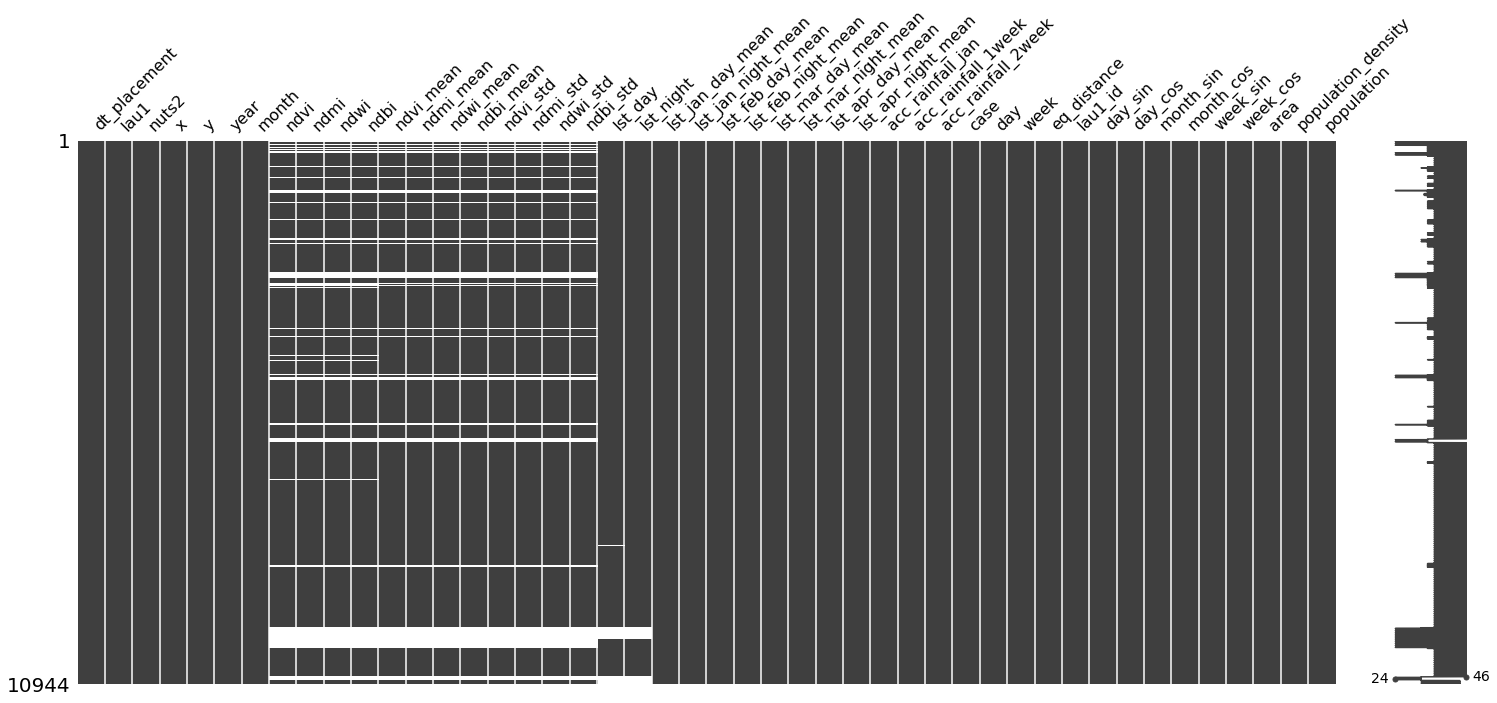

In [46]:
missingno.matrix(dataset)

In [47]:
missing = describe_dataframe(dataset)

In [48]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14254.250000,13999.75,14038.416667,13841.023810,14155.566667,13756.638258,14594.434470,13873.434314,15130.728022,14121.996545,0.015560,0.015560,0.015560,0,1,53,46.44911,8,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,478.8,86.8,38293.0
1,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14223.727273,13957.00,13869.513312,13744.208815,13867.496753,13711.131484,14224.720029,13763.856185,14598.699282,13988.568853,0.248551,0.248551,0.248551,0,1,53,46.48134,9,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,985.8,28.0,24924.0
2,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.00,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,0.000000,0.000000,0.000000,0,1,53,46.65786,17,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,9.8,5319.1,49674.0
3,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14313.500000,14075.75,14060.466667,13849.123810,14119.082323,13755.281926,14385.038636,13831.014839,14687.678342,14072.125000,0.055994,0.055994,0.055994,0,1,53,47.42581,33,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,411.8,22.3,7169.0
4,2010-01-01,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2010,1,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.000000,0.000000,0.000000,0.000000,14419.500000,14040.25,14128.136995,13903.784226,14068.485978,13793.050847,14424.248689,13827.634516,14601.602841,14032.383996,1.750566,1.750566,1.750566,0,1,53,46.91682,27,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,747.0,24.5,16994.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10939,2021-12-16,σιθωνιας,κεντρικης μακεδονιας,23.82811,40.11026,2021,12,0.533019,0.216610,-0.406977,-0.216610,0.525750,0.209897,-0.401147,-0.209897,0.039324,0.061157,0.034067,0.061157,NaN,NaN,14131.712105,13798.223434,14309.703516,13947.082353,14391.596265,13919.650000,14628.870760,14012.311944,2180.544076,75.411011,161.899452,0,16,50,46.65417,16,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,516.8,24.0,11631.0
10940,2021-12-16,σιντικης,κεντρικης μακεδονιας,23.38806,41.31348,2021,12,0.126568,-0.005089,-0.091934,0.005089,0.122184,0.074416,-0.090676,-0.074416,0.027041,0.050254,0.035247,0.050254,NaN,NaN,13895.539899,13525.684019,14245.385339,13792.929034,14454.229025,13724.788455,14684.146065,13885.721902,1562.784564,141.524710,215.682589,0,16,50,47.47426,35,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,1103.4,20.1,18532.0
10941,2021-12-16,σκυδρας,κεντρικης μακεδονιας,22.14670,40.82294,2021,12,0.424823,0.260152,-0.272072,-0.260152,0.423505,0.247285,-0.273696,-0.247285,0.023733,0.043566,0.046055,0.043566,NaN,NaN,14058.867424,13572.800000,14466.912879,13843.509211,14590.182353,13825.676471,14830.247917,13975.117647,997.526490,56.599638,67.029917,0,16,50,46.44339,7,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,239.5,84.3,18080.0
10942,2021-12-16,χαλκηδονος,κεντρικης μακεδονιας,22.72302,40.75357,2021,12,0.255928,-0.052975,-0.231818,0.052975

In [49]:
mosquito_data = read_data(f'data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [50]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [51]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'CENTRAL MACEDONIA'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [52]:
mosq_columns = mosquito_data_nuts2.columns

In [53]:
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [54]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


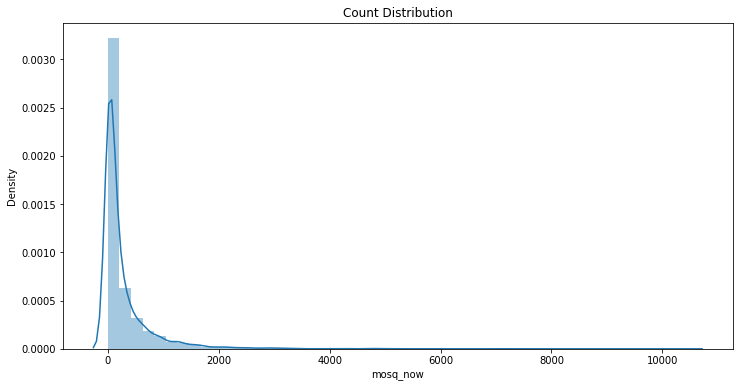

In [55]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [56]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

C:\Users\dimit\AppData\Local\Temp/ipykernel_7140/187358562.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


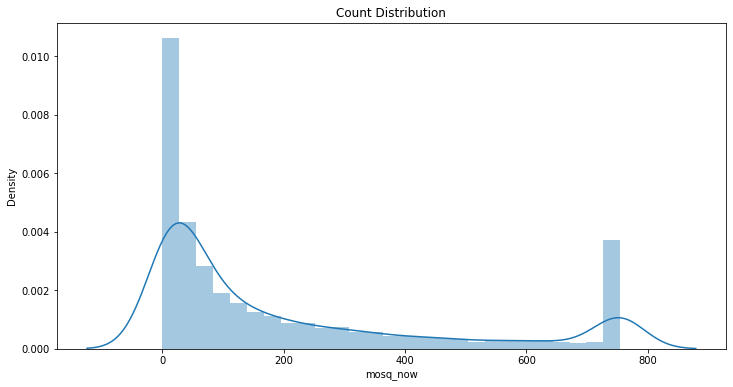

In [57]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

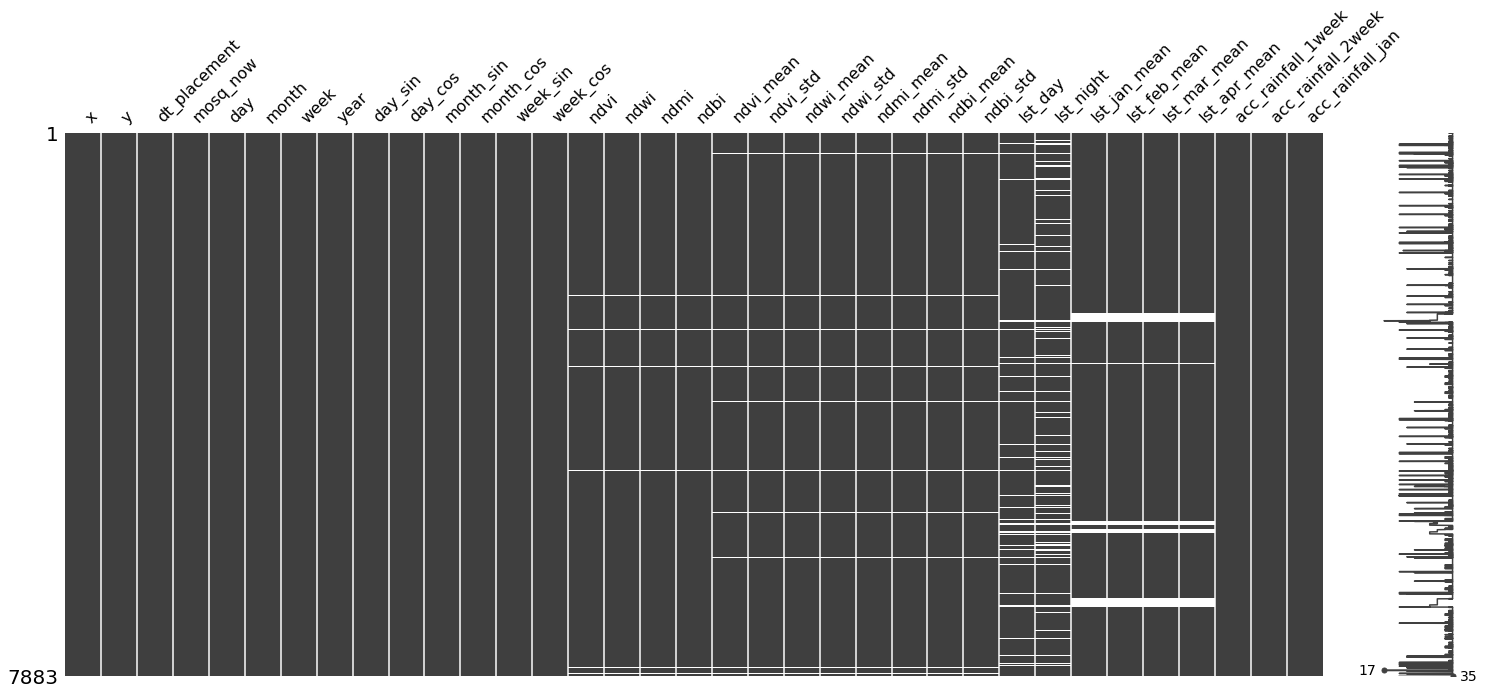

In [58]:
missingno.matrix(mosquito_data_nuts2)

In [59]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [60]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

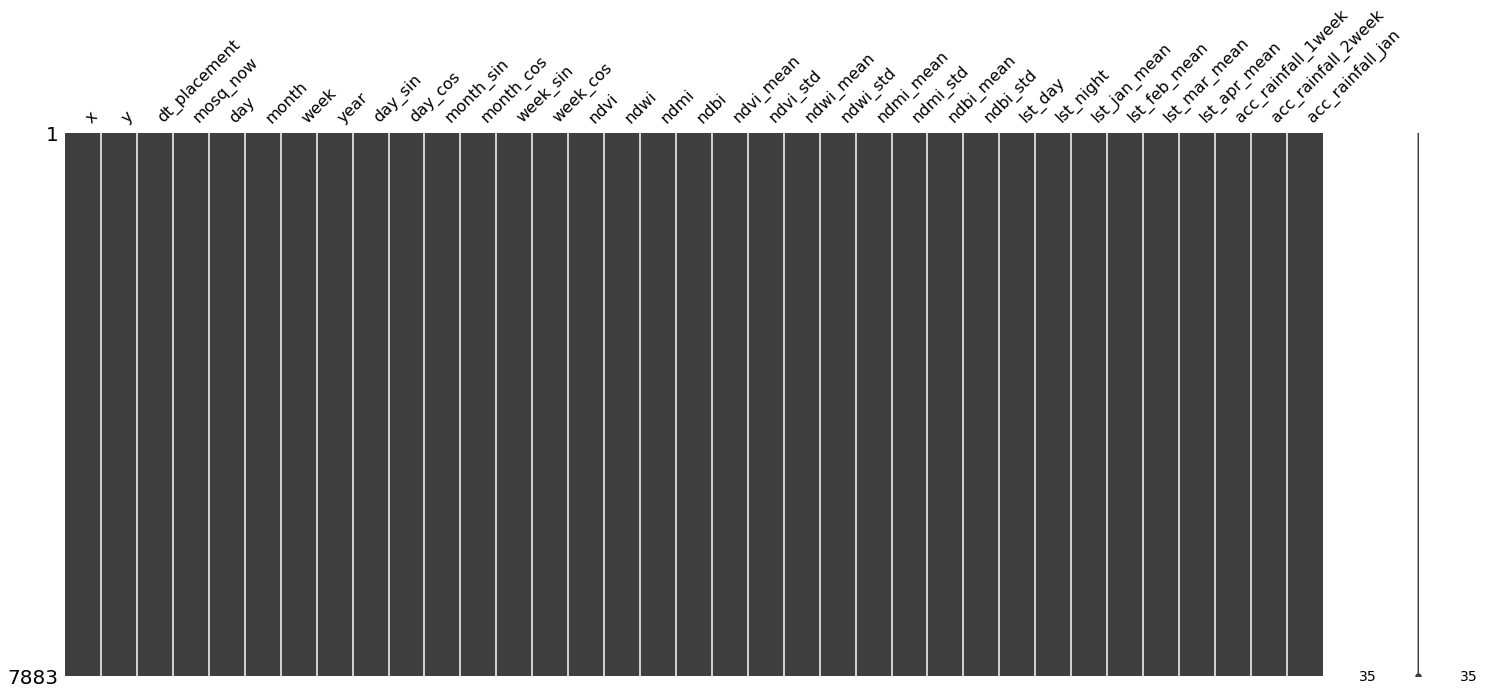

In [61]:
missingno.matrix(mosquito_data_nuts2)

In [62]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [63]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


In [64]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 11.93481 | Val Loss: 24.57893 | Train Acc: 1.328| Val Acc: 1.940
Epoch 002: | Train Loss: 11.94552 | Val Loss: 25.07800 | Train Acc: 1.323| Val Acc: 2.037
Epoch 003: | Train Loss: 11.88296 | Val Loss: 24.42598 | Train Acc: 1.300| Val Acc: 1.937
Epoch 004: | Train Loss: 11.88441 | Val Loss: 24.92590 | Train Acc: 1.341| Val Acc: 1.991
Epoch 005: | Train Loss: 11.83432 | Val Loss: 24.90104 | Train Acc: 1.310| Val Acc: 1.993
Epoch 006: | Train Loss: 11.87377 | Val Loss: 24.52142 | Train Acc: 1.328| Val Acc: 1.940
Epoch 007: | Train Loss: 11.94032 | Val Loss: 24.28345 | Train Acc: 1.314| Val Acc: 1.947
Epoch 008: | Train Loss: 11.79763 | Val Loss: 24.61821 | Train Acc: 1.305| Val Acc: 1.935
Epoch 009: | Train Loss: 11.79913 | Val Loss: 25.17018 | Train Acc: 1.302| Val Acc: 2.002
Epoch 010: | Train Loss: 11.80332 | Val Loss: 24.59329 | Train Acc: 1.289| Val Acc: 1.915
Epoch 011: | Train Loss: 11.88061 | Val Loss: 24.59025 | Train Acc: 1.303| Val Acc: 1.924
Epoch 012:

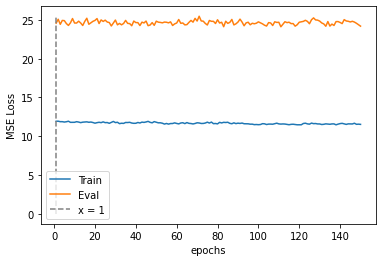

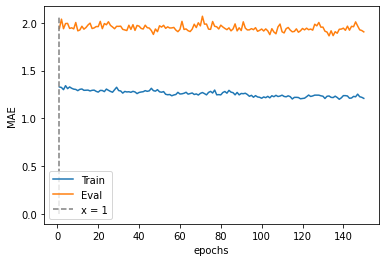

In [67]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [68]:
metrics(train, test, threshold=30)

MAE on train set:  134.81210606203706
min prediction: 1
max prediction: 816

MAE on test set:  149.92492663342696
Error ⩽ 30: 21.28 %
min prediction: 1
max prediction: 746


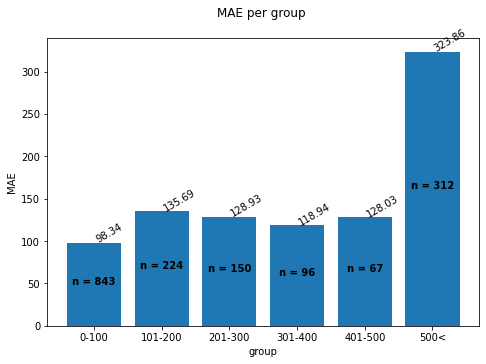

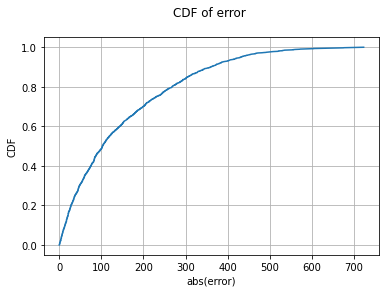

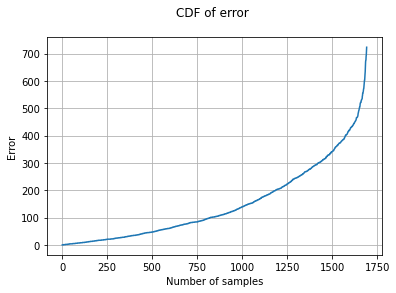

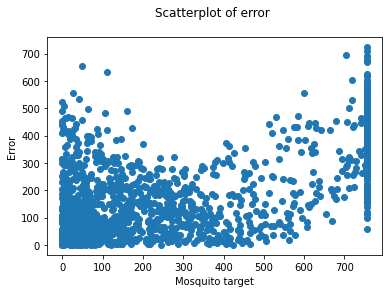

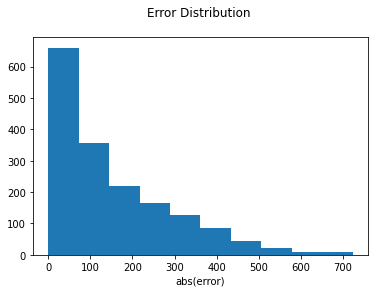

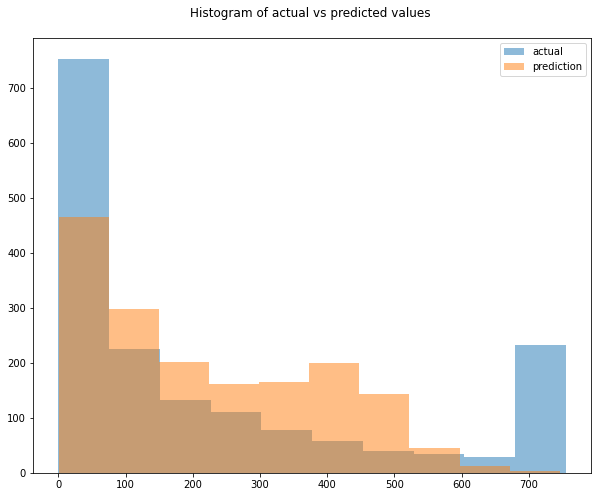

In [69]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.22775 | Val Loss: 2.13712 | Train Acc: 1.489| Val Acc: 1.633
Epoch 002: | Train Loss: 13.66212 | Val Loss: 1.34127 | Train Acc: 1.527| Val Acc: 1.633
Epoch 003: | Train Loss: 13.13991 | Val Loss: 2.90886 | Train Acc: 1.430| Val Acc: 1.633
Epoch 004: | Train Loss: 13.19765 | Val Loss: 3.76098 | Train Acc: 1.462| Val Acc: 1.633
Epoch 005: | Train Loss: 12.75508 | Val Loss: 3.84429 | Train Acc: 1.397| Val Acc: 1.633
Epoch 006: | Train Loss: 13.00753 | Val Loss: 1.99891 | Train Acc: 1.427| Val Acc: 1.633
Epoch 007: | Train Loss: 12.78187 | Val Loss: 2.94221 | Train Acc: 1.413| Val Acc: 1.633
Epoch 008: | Train Loss: 12.86227 | Val Loss: 4.36967 | Train Acc: 1.427| Val Acc: 1.633
Epoch 009: | Train Loss: 12.62143 | Val Loss: 2.02560 | Train Acc: 1.389| Val Acc: 1.633
Epoch 010: | Train Loss: 12.74925 | Val Loss: 3.21935 | Train Acc: 1.423| Val Acc: 1.633
Epoch 011: | Train Loss: 12.87625 | Val Loss: 3.97018 | Train Acc: 1.411| Val Acc: 1.633
Epoch 012: | Train Lo

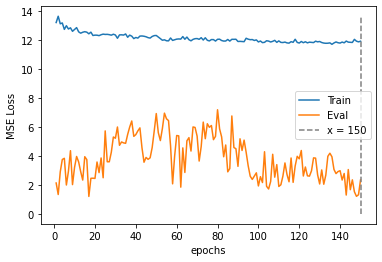

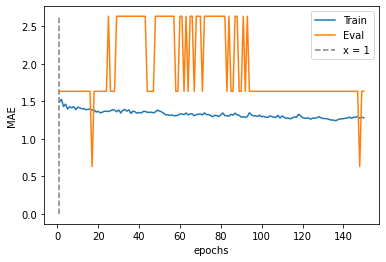

In [70]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [71]:
# mamoth_columns = ['x','y','dt_placement','day','month','week','year', 
#                   'day_sin','day_cos','month_sin','month_cos','week_sin','week_cos',
#                   'ndvi','ndmi','ndwi','ndbi', 'ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean', 
#                   'ndvi_std','ndmi_std','ndwi_std','ndbi_std',
#                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean', 
#                   'acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_jan', 'mosq_now' ]

In [72]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [73]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [74]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [75]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [76]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [77]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

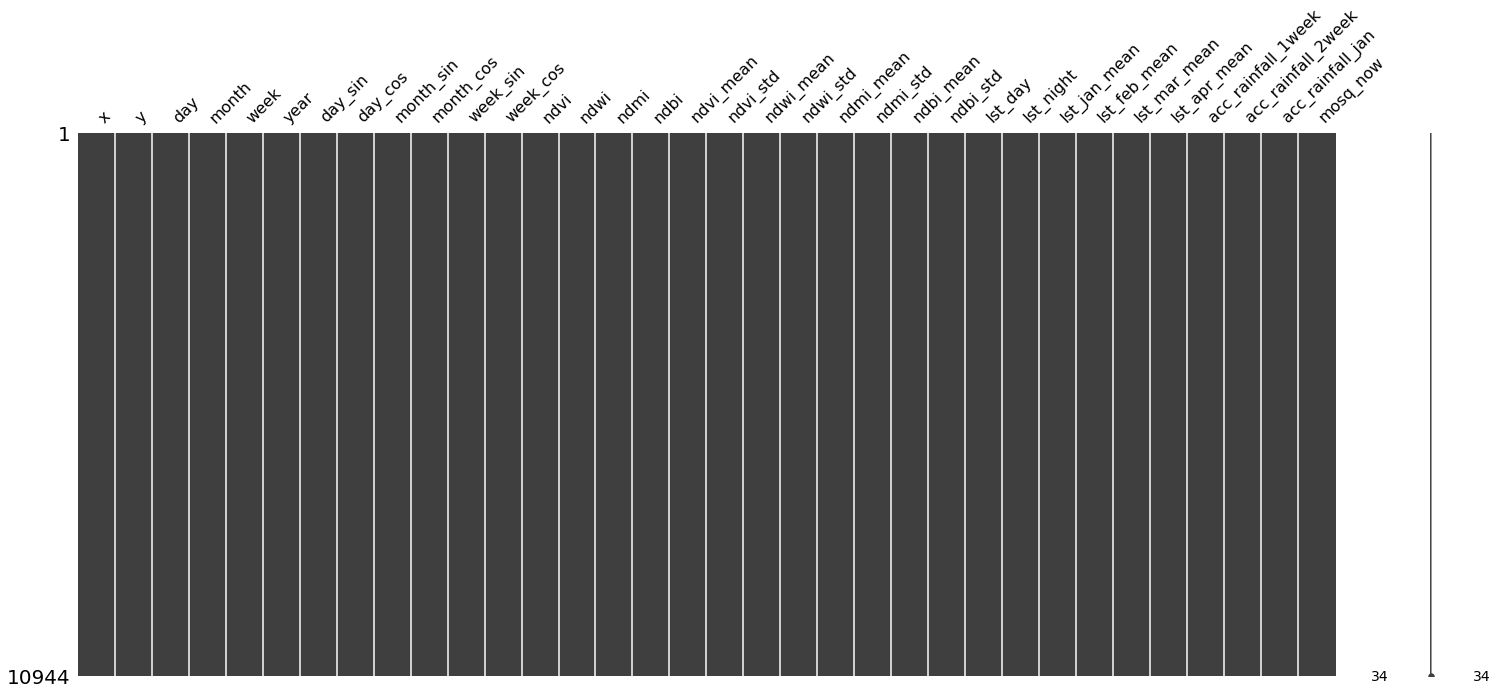

In [78]:
missingno.matrix(dataset_mamoth)

In [79]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [80]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [81]:
predictions = give_predictions(model, dataset_mamoth)

In [82]:
mosqutio_predictions['mosq_pred'] = predictions

In [83]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.48398,40.64468,2010-01-01,9
1,21.94079,40.97703,2010-01-01,12
2,22.89198,40.65603,2010-01-01,12
3,23.98253,40.91510,2010-01-01,13
4,23.69108,40.49593,2010-01-01,17
...,...,...,...,...
10939,23.82811,40.11026,2021-12-16,6
10940,23.38806,41.31348,2021-12-16,2
10941,22.14670,40.82294,2021-12-16,22
10942,22.72302,40.75357,2021-12-16,44


In [84]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x','y','dt_placement'])

In [85]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14254.250000,13999.75,14038.416667,13841.023810,14155.566667,13756.638258,14594.434470,13873.434314,15130.728022,14121.996545,0.015560,0.015560,0.015560,0,1,53,46.44911,8,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,478.8,86.8,38293.0,9
1,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14223.727273,13957.00,13869.513312,13744.208815,13867.496753,13711.131484,14224.720029,13763.856185,14598.699282,13988.568853,0.248551,0.248551,0.248551,0,1,53,46.48134,9,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,985.8,28.0,24924.0,12
2,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.00,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,0.000000,0.000000,0.000000,0,1,53,46.65786,17,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,9.8,5319.1,49674.0,12
3,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14313.500000,14075.75,14060.466667,13849.123810,14119.082323,13755.281926,14385.038636,13831.014839,14687.678342,14072.125000,0.055994,0.055994,0.055994,0,1,53,47.42581,33,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,411.8,22.3,7169.0,13
4,2010-01-01,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2010,1,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.000000,0.000000,0.000000,0.000000,14419.500000,14040.25,14128.136995,13903.784226,14068.485978,13793.050847,14424.248689,13827.634516,14601.602841,14032.383996,1.750566,1.750566,1.750566,0,1,53,46.91682,27,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,747.0,24.5,16994.0,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10939,2021-12-16,σιθωνιας,κεντρικης μακεδονιας,23.82811,40.11026,2021,12,0.533019,0.216610,-0.406977,-0.216610,0.525750,0.209897,-0.401147,-0.209897,0.039324,0.061157,0.034067,0.061157,NaN,NaN,14131.712105,13798.223434,14309.703516,13947.082353,14391.596265,13919.650000,14628.870760,14012.311944,2180.544076,75.411011,161.899452,0,16,50,46.65417,16,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,516.8,24.0,11631.0,6
10940,2021-12-16,σιντικης,κεντρικης μακεδονιας,23.38806,41.31348,2021,12,0.126568,-0.005089,-0.091934,0.005089,0.122184,0.074416,-0.090676,-0.074416,0.027041,0.050254,0.035247,0.050254,NaN,NaN,13895.539899,13525.684019,14245.385339,13792.929034,14454.229025,13724.788455,14684.146065,13885.721902,1562.784564,141.524710,215.682589,0,16,50,47.47426,35,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,1103.4,20.1,18532.0,2
10941,2021-12-16,σκυδρας,κεντρικης μακεδονιας,22.14670,40.82294,2021,12,0.424823,0.260152,-0.272072,-0.260152,0.423505,0.247285,-0.273696,-0.247285,0.023733,0.043566,0.046055,0.043566,NaN,NaN,14058.867424,13572.800000,14466.912879,13843.509211,14590.182353,13825.676471,14830.247917,13975.117647,997.526490,56.599638,67.029917,0,16,50,46.44339,7,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,239.5,84.3,18080.0,22
10942,2021-12-16,χαλκηδονος,κεντρικης μακεδονιας,22.72302,40.75357,2021,12,0.

<AxesSubplot:>

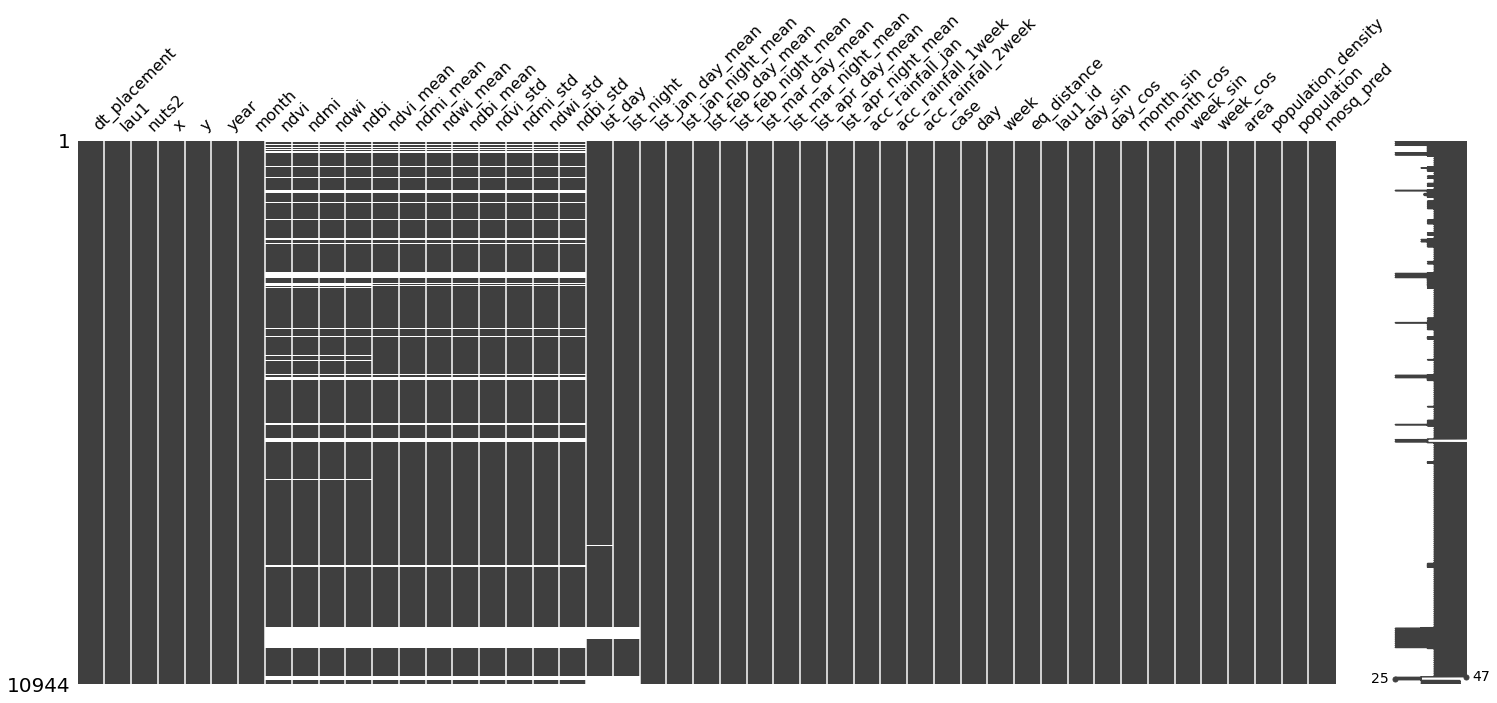

In [86]:
missingno.matrix(dataset)

In [87]:
dataset.reset_index(inplace=True, drop=True)

In [88]:
dataset = calculate_mosq_previous(dataset)

In [89]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

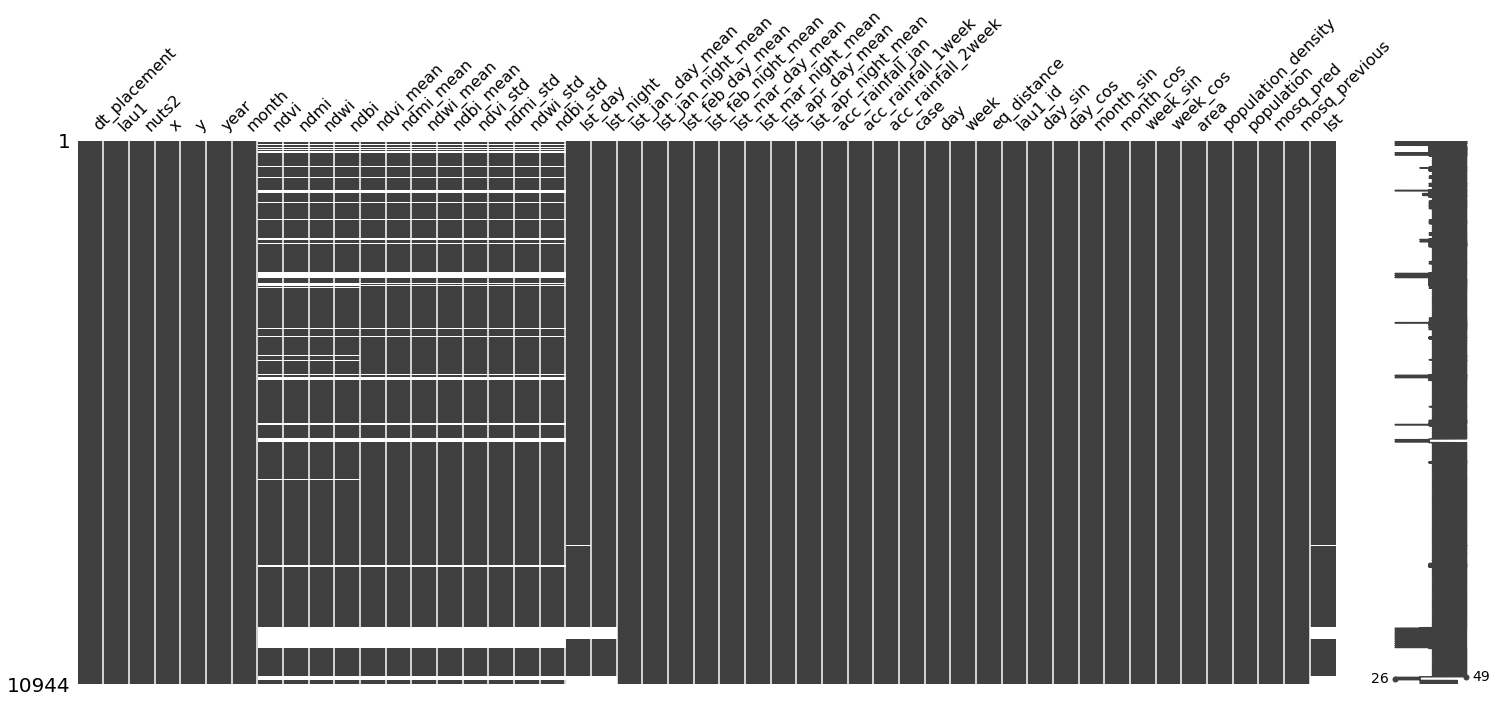

In [90]:
missingno.matrix(dataset)

In [91]:
dataset['case'].value_counts()

0     10608
1       212
2        61
3        23
4        20
      ...  
6         2
11        1
18        1
12        1
9         1
Name: case, Length: 13, dtype: int64

In [92]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [93]:
dataset = convert_multiple_cases(dataset)

In [94]:
dataset['case'].value_counts()

0    10608
1      632
Name: case, dtype: int64

In [95]:
cols = dataset.columns

In [96]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'lau1_id', 'day_sin', 'day_cos',
       'month_sin', 'month_cos', 'week_sin', 'week_cos', 'area',
       'population_density', 'population', 'mosq_pred', 'mosq_previous',
       'lst'],
      dtype='object')

In [97]:
len(cols)

49

In [98]:
# check columns

In [99]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'lau1_id', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [100]:
len(final_columns)

49

In [101]:
dataset_final = dataset[final_columns].copy()

In [102]:
dataset_final

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,8,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.390000,11.935000,6.845,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,0.015560,0.015560,0.015560,9,0,0
1,21.94079,40.97703,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,9,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,985.8,24924.0,28.0,46.48134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.657273,11.324545,5.990,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,0.248551,0.248551,0.248551,12,0,0
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,17,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,12,0,0
3,23.98253,40.91510,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,33,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,411.8,7169.0,22.3,47.42581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.742500,13.120000,8.365,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,0.055994,0.055994,0.055994,13,0,0
4,23.69108,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,27,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,747.0,16994.0,24.5,46.91682,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.000000,0.000000,0.000000,0.000000,11.447500,15.240000,7.655,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,1.750566,1.750566,1.750566,17,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11235,22.41285,40.81412,2018-08-16,κεντρικης μακεδονιας,πελλας,13,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,669.2,56918.0,94.3,46.56316,0.458799,0.094423,-0.417326,-0.094423,0.425498,0.082706,-0.393120,-0.082706,0.108684,0.072249,0.084478,0.072249,27.882000,34.258000,21.506,11.166473,0.115267,14.108900,1.406167,20.498747,6.152633,28.072005,12.348017,0.498782,9.606998,761.377052,40,104,1
11236,22.41285,40.81412,2018-08-16,κεντρικης μακεδονιας,πελλας,13,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,669.2,56918.0,94.3,46.56316,0.458799,0.094423,-0.417326,-0.094423,0.425498,0.082706,-0.393120,-0.082706,0.108684,0.072249,0.084478,0.072249,27.882000,34.258000,21.506,11.166473,0.115267,14.108900,1.406167,20.498747,6.152633,28.072005,12.348017,0.498782,9.606998,761.377052,40,104,1
11237,22.41285,40.81412,2018-08-16,κεντρικης μακεδονιας,πελλας,13,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,669.2,56918.0,94.3,46.56316,0.458799,0.094423,-0.417326,-0.094423,0.425498,0.082706,-0.393120,-0.082706,0.108684,0.072249,0.084478,0.072249,27.882000,34.258000,21.506,11.166473,0.115267,14.108900,1.406167,20.498747,6.152633,28.072005,12.348017,0.498782,9.606998,761.377052,40,104,1
11238,22.41285,40.81412,2018-08-16,κεντρικης μακεδονιας,πελλας,13,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,669.2,56918.0,94.3,46.56316,0.458799,0.094423,-0.417326,-0.094423,0.425498,

In [103]:
dataset_final.to_csv(f"data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv", encoding = enc, index = False)